# TabM：任务时间与能耗预测（简化版）

本 Notebook 只使用 **TabM**，分别训练两个回归模型：

- `task_duration_min`：去除 `speed < 0.2` 暂停时间后的任务时长，单位为分钟；
- `total_energy_soc_delta_pct`：任务 SOC 能耗，单位为百分点。

流程：读取 JSON → 按时间顺序划分 → 中位数填补与标准化 → 早停确定 epoch → 完整训练集重训 → 测试集评价 → 绘图与保存结果。

> 只需要先修改下一节的 `DATA_FILE` 和 `OUTPUT_DIR`。

## 1. 首次安装或修复依赖

首次安装时运行第一组命令。你之前出现过 `backend_agg` 导入失败；若再次出现，运行第二组“清洁重装 Matplotlib”命令，然后 **重启 Kernel**。

In [74]:
# 首次安装依赖时取消注释并运行：
# %pip install -U numpy pandas scikit-learn joblib torch tabm matplotlib matplotlib-inline

# # Matplotlib 的 backend_agg 损坏时，取消注释并运行；完成后必须重启 Kernel：
# %pip install --force-reinstall --no-deps matplotlib==3.11.1
# %pip uninstall -y matplotlib matplotlib-inline
# %pip install --no-cache-dir --force-reinstall matplotlib matplotlib-inline

## 2. 导入依赖与配置

In [75]:
import os

os.environ.setdefault("MPLBACKEND", "Agg")         # 保持图片，不弹窗
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")   # 4核

import json
import math
import random
import re
from copy import deepcopy
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPythonImage
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)   # DF显示最多120列
pd.set_option("display.width", 200)         # DF显示宽度200字符
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]    # 字体设置
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch 设备：", DEVICE)
if DEVICE.type == "cuda":
    print("GPU：", torch.cuda.get_device_name(0))

PyTorch 设备： cpu


In [76]:
# 1、路径配置
PROJECT_ROOT = Path(globals()["_dh"][0]).resolve().parent

DATA_FILE = PROJECT_ROOT / "data" / "任务特征和标签_20米_去除暂停时间.json"
OUTPUT_DIR = PROJECT_ROOT / "target" / "TabM_Simple"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 2、特征配置
CORE_FEATURE_COLS = [
    "straight_line_distance_m",
    "planned_total_distance_m",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    "planned_slope_std",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    "vehicle_prev1_duration_sec",

    "similar_task_actual_distance_km",
    "similar_task_duration_min",
    "similar_task_energy_soc_delta_pct",
    "similar_top3_duration_mean_sec",
    "similar_top3_od_distance_mean_m",

    "fleet_prev60m_speed_mean",
    "fleet_prev60m_speed_min",
]
# 这些辅助字段同样在任务开始前可获得，但默认不加入模型。
# 改为 True 后，可以检查它们是否能进一步提高性能。
USE_QUALITY_FEATURES = False

QUALITY_FEATURE_COLS = [
    "vehicle_prev5_task_count",
    "similar_task_od_distance_m",
    "similar_task_time_gap_min",
]

FEATURE_COLS = (
    CORE_FEATURE_COLS + QUALITY_FEATURE_COLS
    if USE_QUALITY_FEATURES
    else CORE_FEATURE_COLS
)

# 3、目标label配置
TIME_TARGET = "task_duration_min"
ENERGY_TARGET = "total_energy_soc_delta_pct"

# 4、超参数配置
# 4.1、数据划分：前 80% 训练，后 20% 测试；训练集尾部 15% 用于早停。
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.15

# 4.2、 TabM 参数
BATCH_SIZE = 128
MAX_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 40
MIN_DELTA = 1e-5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 3e-4

# 4.3、 TabM 模型配置
TABM_CONFIG = {
    "arch_type": "tabm",
    "n_blocks": 2,      # 残差块数
    "d_block": 128,     # 每个残差块的维度
    "dropout": 0.10,    # Dropout 率
    "k": 16,            # 集成器数量
}

SAVE_MODELS = True
PLOT_DPI = 150

print("数据文件：", DATA_FILE)
print("输出目录：", OUTPUT_DIR)
print("输入特征数：", len(FEATURE_COLS))
for col in FEATURE_COLS:
    print(" -", col)

数据文件： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\data\任务特征和标签_20米_去除暂停时间.json
输出目录： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple
输入特征数： 15
 - straight_line_distance_m
 - planned_total_distance_m
 - endpoint_altitude_change_m
 - planned_slope_mean
 - planned_slope_std
 - planned_cumulative_ascent_m
 - planned_cumulative_descent_m
 - vehicle_prev1_duration_sec
 - similar_task_actual_distance_km
 - similar_task_duration_min
 - similar_task_energy_soc_delta_pct
 - similar_top3_duration_mean_sec
 - similar_top3_od_distance_mean_m
 - fleet_prev60m_speed_mean
 - fleet_prev60m_speed_min


## 3. 读取和清洗数据

In [77]:
def load_task_dataset(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        raise FileNotFoundError(f"数据文件不存在：{json_path}")

    with json_path.open("r", encoding="utf-8-sig") as file:
        raw = json.load(file)

    if isinstance(raw, list):
        records = raw
    else:
        raise ValueError("JSON 顶层必须是任务数组")

    df = pd.DataFrame(records)    # 字典列表转DataFrame

    # 检查必填字段是否存在
    required = {
        "task_id", "actual_start_time", "actual_end_time",
        TIME_TARGET, ENERGY_TARGET, *FEATURE_COLS,
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError("JSON 缺少以下字段：" + "\n".join(missing))

    df["actual_start_time"] = pd.to_datetime(df["actual_start_time"], errors="coerce")
    df["actual_end_time"] = pd.to_datetime(df["actual_end_time"], errors="coerce")

    numeric_cols = list(dict.fromkeys(FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]))
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    initial_count = len(df)   # 原始任务数
    df = df.dropna(subset=["task_id", "actual_start_time", TIME_TARGET, ENERGY_TARGET])

    # 当前任务本身的路线特征必须存在；历史特征允许缺失，后续用训练集的中位数填补。
    required_current_features = [
        "straight_line_distance_m",
        "planned_total_distance_m",
        "endpoint_altitude_change_m",
        "planned_slope_mean",
        "planned_slope_std",
    ]
    df = df.dropna(subset=required_current_features)

    df = df[(df[TIME_TARGET] >= 0) & (df[ENERGY_TARGET] >= 0)].copy()    # 简单过滤
    df = df.drop_duplicates(subset="task_id", keep="first")              # 去重
    df = df.sort_values(
        ["actual_start_time", "actual_end_time", "task_id"]
    ).reset_index(drop=True)                                             # 按时间排序

    print("原始任务数：", initial_count)
    print("清洗后任务数：", len(df))
    print("删除任务数：", initial_count - len(df))
    return df


df = load_task_dataset(DATA_FILE)

print("\n标签统计：")
display(df[[TIME_TARGET, ENERGY_TARGET]].describe().T.round(4))

print("\n特征缺失数量：")
missing_table = df[FEATURE_COLS].isna().sum().sort_values(ascending=False)
display(missing_table.rename("missing_count").to_frame())

display(df.head(3))

原始任务数： 3210
清洗后任务数： 3193
删除任务数： 17

标签统计：


,count,mean,std,min,25%,50%,75%,max
task_duration_min,3193.0,18.1323,2.8083,11.8165,16.0175,17.9183,20.4831,30.8833
total_energy_soc_delta_pct,3193.0,14.5826,2.5758,9.2000,12.4000,14.0000,16.8000,21.2000



特征缺失数量：


,missing_count
vehicle_prev1_duration_sec,10
fleet_prev60m_speed_min,7
fleet_prev60m_speed_mean,7
similar_task_actual_distance_km,3
similar_top3_od_distance_mean_m,3
similar_task_duration_min,3
similar_task_energy_soc_delta_pct,3
similar_top3_duration_mean_sec,3
planned_cumulative_descent_m,0
planned_slope_std,0


,task_id,transport_device_id,task_type_id,sn,source_file,source_task_index,actual_start_time,actual_end_time,start_longitude,start_latitude,end_longitude,end_latitude,straight_line_distance_m,task_duration_min,total_energy_soc_delta_pct,planned_total_distance_m,start_altitude_m,end_altitude_m,endpoint_altitude_change_m,start_altitude_source,end_altitude_source,start_altitude_nearest_distance_m,end_altitude_nearest_distance_m,planned_lane_distance_m_debug,planned_snap_distance_m,planned_jump_distance_m,planned_lane_count,planned_lane_uids,planned_route_sample_count,planned_route_candidate_count,route_planning_error,planned_slope_mean,planned_slope_std,planned_cumulative_ascent_m,planned_cumulative_descent_m,planned_altitude_sample_count,vehicle_prev5_gps_speed_mean,vehicle_prev5_task_count,vehicle_prev5_speed_record_count,vehicle_prev1_duration_sec,vehicle_prev5_duration_mean_sec,vehicle_prev1_duration_min,vehicle_prev5_duration_mean_min,similar_task_gps_speed_mean,similar_task_actual_distance_km,similar_task_duration_sec,similar_task_duration_min,similar_task_energy_soc_delta_pct,similar_task_energy_count,similar_top3_duration_mean_sec,similar_top3_duration_median_sec,similar_top3_duration_std_sec,similar_top3_duration_mean_min,similar_top3_duration_median_min,similar_top3_duration_std_min,similar_top3_od_distance_mean_m,similar_task_actual_distance_count,similar_task_count,similar_task_speed_record_count,similar_task_od_distance_m,similar_task_time_gap_min,similar_task_source_task_ids,similar_task_source_sns,similar_task_candidate_count,fleet_prev30m_speed_mean,fleet_prev60m_speed_mean,fleet_prev60m_speed_min,fleet_prev60m_speed_record_count
0,8061142448472321,55396247774017,102,TLE00860VR1450018,TLE00860VR1450018最终有效卸料任务.json,0,2026-06-08 00:01:03.574,2026-06-08 00:21:25.007,89.273817,44.833821,89.247362,44.835466,2094.050383,18.830267,17.2,3789.101299,557.6221,731.5153,173.8932,gps_idw,gps_idw,0.0,0.0,3586.877042,202.224257,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",181,12,None,0.042151,0.032896,152.272,0.675,181,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,NaN,NaN,NaN,0
1,8061154458370305,55564864593345,102,TLE00900VR1450048,TLE00900VR1450048最终有效卸料任务.json,0,2026-06-08 00:13:16.719,2026-06-08 00:32:44.095,89.277059,44.833191,89.247351,44.835450,2355.996519,18.216533,15.6,3826.896119,568.9714,731.4607,162.4893,gps_idw,gps_idw,0.0,0.0,3790.988348,35.907771,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",191,12,None,0.043635,0.033548,165.600,0.608,191,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,3.909069,3.909069,0.004,734
2,8061162448994561,55537321185345,102,TLE00900AR1450052,TLE00900AR1450052最终有效卸料任务.json,0,2026-06-08 00:21:24.336,2026-06-08 00:38:28.099,89.275629,44.836068,89.247369,44.835079,2231.095434,15.982800,12.8,3479.773318,587.6318,731.2242,143.5924,gps_idw,gps_idw,0.0,0.0,3405.940469,73.832849,0.0,5,"[56874960260993, 56842382339681, 5684246569014...",172,15,None,0.042129,0.033105,144.699,0.771,172,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,[],[],0,3.474775,3.474775,0.002,1709


## 4. 按时间顺序划分训练集、验证集和测试集

In [78]:
test_start = int(len(df) * (1.0 - TEST_SIZE))
train_df = df.iloc[:test_start].copy()    # 训练集
test_df = df.iloc[test_start:].copy()     # 测试集

validation_start = int(len(train_df) * (1.0 - VALIDATION_SIZE_WITHIN_TRAIN))
fit_df = train_df.iloc[:validation_start].copy()         # 拟合集
validation_df = train_df.iloc[validation_start:].copy()  # 验证集

X_train = train_df[FEATURE_COLS].copy()
X_test = test_df[FEATURE_COLS].copy()

y_time_train = train_df[TIME_TARGET].astype(float).copy()
y_time_test = test_df[TIME_TARGET].astype(float).copy()
y_energy_train = train_df[ENERGY_TARGET].astype(float).copy()
y_energy_test = test_df[ENERGY_TARGET].astype(float).copy()

assert fit_df["actual_start_time"].max() <= validation_df["actual_start_time"].min()
assert train_df["actual_start_time"].max() <= test_df["actual_start_time"].min()

print("早停拟合集：", fit_df.shape)
print("早停验证集：", validation_df.shape)
print("完整训练集：", train_df.shape)
print("测试集：", test_df.shape)
print("\n训练时间：", train_df["actual_start_time"].min(), "至", train_df["actual_start_time"].max())
print("测试时间：", test_df["actual_start_time"].min(), "至", test_df["actual_start_time"].max())

早停拟合集： (2170, 68)
早停验证集： (384, 68)
完整训练集： (2554, 68)
测试集： (639, 68)

训练时间： 2026-06-08 00:01:03.574000 至 2026-07-04 06:25:38.001000
测试时间： 2026-07-04 06:25:58.011000 至 2026-07-07 23:03:05.110000


## 5. TabM 训练函数

In [79]:
from tabm import TabM

def make_feature_preprocessor() -> Tuple[SimpleImputer, StandardScaler]:
    # add_indicator=True 会额外告诉模型哪些字段原本缺失。
    return SimpleImputer(strategy="median", add_indicator=True), StandardScaler()


def fit_transform_features(X_fit: pd.DataFrame, X_other: pd.DataFrame) -> Tuple[np.ndarray,
    np.ndarray, SimpleImputer, StandardScaler]:

    imputer, scaler = make_feature_preprocessor()
    X_fit_array = scaler.fit_transform(imputer.fit_transform(X_fit)).astype(np.float32)
    X_other_array = scaler.transform(imputer.transform(X_other)).astype(np.float32)
    return X_fit_array, X_other_array, imputer, scaler


def transform_features(X: pd.DataFrame, imputer: SimpleImputer,scaler: StandardScaler) -> np.ndarray:
    return scaler.transform(imputer.transform(X)).astype(np.float32)


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool, seed: int = RANDOM_STATE) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(np.asarray(X, dtype=np.float32)),
        torch.from_numpy(np.asarray(y, dtype=np.float32)),
    )
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=shuffle,
        generator=generator if shuffle else None,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


def make_tabm_model(n_features: int) -> nn.Module:
    return TabM.make(n_num_features=n_features, d_out=1, **TABM_CONFIG)


@torch.no_grad()
def predict_standardized(model: nn.Module, X: np.ndarray) -> np.ndarray:
    model.eval()
    loader = make_loader(X, np.zeros((len(X), 1), dtype=np.float32), shuffle=False)
    predictions = []
    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        # TabM 输出 (batch, k, 1)，推理时对 k 个成员取平均。
        pred = model(xb).mean(dim=1).squeeze(-1)
        predictions.append(pred.cpu().numpy())
    return np.concatenate(predictions)


def train_tabm_core(X_fit: np.ndarray, y_fit_std: np.ndarray, X_val: Optional[np.ndarray] = None,
    y_val_std: Optional[np.ndarray] = None, max_epochs: int = MAX_EPOCHS, patience: int =
    EARLY_STOPPING_PATIENCE) -> Tuple[nn.Module, int, Dict[str, list]]:

    set_seed()
    model = make_tabm_model(X_fit.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader(X_fit, y_fit_std.reshape(-1, 1), shuffle=True)

    use_validation = X_val is not None and y_val_std is not None
    best_state = deepcopy(model.state_dict())
    best_epoch = 1
    best_val_rmse = math.inf
    bad_epochs = 0
    history = {"train_loss": [], "val_rmse_std": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True).squeeze(-1)

            optimizer.zero_grad(set_to_none=True)
            pred_all = model(xb).squeeze(-1)  # (batch, k)
            target_all = yb[:, None].expand_as(pred_all)
            loss = F.smooth_l1_loss(pred_all, target_all)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            batch_size = xb.shape[0]
            total_loss += float(loss.item()) * batch_size
            total_count += batch_size

        train_loss = total_loss / max(total_count, 1)
        history["train_loss"].append(train_loss)

        if use_validation:
            val_pred = predict_standardized(model, X_val)
            val_rmse = float(mean_squared_error(y_val_std, val_pred) ** 0.5)
            history["val_rmse_std"].append(val_rmse)

            if val_rmse < best_val_rmse - MIN_DELTA:
                best_val_rmse = val_rmse
                best_epoch = epoch
                best_state = deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1

            if epoch == 1 or epoch % 20 == 0:
                print(
                    f"Epoch {epoch:03d} | train loss={train_loss:.5f} | "
                    f"val RMSE(std)={val_rmse:.5f}"
                )

            if bad_epochs >= patience:
                print(
                    f"早停：best_epoch={best_epoch}, "
                    f"best_val_RMSE(std)={best_val_rmse:.5f}"
                )
                break
        elif epoch == 1 or epoch % 20 == 0 or epoch == max_epochs:
            print(f"Epoch {epoch:03d} | train loss={train_loss:.5f}")

    if use_validation:
        model.load_state_dict(best_state)

    return model, best_epoch, history


def fit_tabm_target(X_train_df: pd.DataFrame, y_train: pd.Series, X_test_df: pd.DataFrame,
    target_name: str) -> Dict[str, Any]:
    # 阶段 1：训练集尾部验证，确定最佳 epoch。
    X_fit_df = X_train_df.iloc[:validation_start].copy()
    X_val_df = X_train_df.iloc[validation_start:].copy()
    y_fit = y_train.iloc[:validation_start].to_numpy(dtype=np.float32)
    y_val = y_train.iloc[validation_start:].to_numpy(dtype=np.float32)

    X_fit, X_val, _, _ = fit_transform_features(X_fit_df, X_val_df)
    validation_target_scaler = StandardScaler()
    y_fit_std = validation_target_scaler.fit_transform(y_fit.reshape(-1, 1)).ravel().astype(np.float32)
    y_val_std = validation_target_scaler.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)

    print(f"\n[{target_name}] 阶段 1：早停选择 epoch")
    _, best_epoch, history = train_tabm_core(X_fit, y_fit_std, X_val, y_val_std)

    # 阶段 2：在完整训练集上按最佳 epoch 重新训练。
    imputer, feature_scaler = make_feature_preprocessor()
    X_train_full = feature_scaler.fit_transform(imputer.fit_transform(X_train_df)).astype(np.float32)
    X_test_full = transform_features(X_test_df, imputer, feature_scaler)

    target_scaler = StandardScaler()
    y_train_std = target_scaler.fit_transform(
        y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
    ).ravel().astype(np.float32)

    print(f"[{target_name}] 阶段 2：完整训练集训练 {best_epoch} 个 epoch")
    final_model, _, _ = train_tabm_core(
        X_train_full,
        y_train_std,
        max_epochs=best_epoch,
        patience=best_epoch + 1,
    )

    prediction_std = predict_standardized(final_model, X_test_full)
    prediction = target_scaler.inverse_transform(prediction_std.reshape(-1, 1)).ravel()

    return {
        "model": final_model,
        "prediction": prediction,
        "best_epoch": best_epoch,
        "history": history,
        "imputer": imputer,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
    }

## 6. 分别训练任务时间和任务能耗 TabM

In [80]:
print("=" * 80)
print("训练 TabM：任务时间")
time_bundle = fit_tabm_target(X_train, y_time_train, X_test, target_name="任务时间")

print("\n" + "=" * 80)
print("训练 TabM：任务能耗")
energy_bundle = fit_tabm_target(X_train, y_energy_train, X_test, target_name="任务能耗")

time_pred = np.maximum(time_bundle["prediction"], 0.0)
energy_pred = np.maximum(energy_bundle["prediction"], 0.0)

print("训练完成。")

训练 TabM：任务时间

[任务时间] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.22325 | val RMSE(std)=0.52342
Epoch 020 | train loss=0.03001 | val RMSE(std)=0.33993
Epoch 040 | train loss=0.02811 | val RMSE(std)=0.33080
Epoch 060 | train loss=0.02602 | val RMSE(std)=0.34068
Epoch 080 | train loss=0.02491 | val RMSE(std)=0.33779
Epoch 100 | train loss=0.02418 | val RMSE(std)=0.33722
早停：best_epoch=62, best_val_RMSE(std)=0.32720
[任务时间] 阶段 2：完整训练集训练 62 个 epoch
Epoch 001 | train loss=0.20575
Epoch 020 | train loss=0.03397
Epoch 040 | train loss=0.03113
Epoch 060 | train loss=0.02949
Epoch 062 | train loss=0.03029

训练 TabM：任务能耗

[任务能耗] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.22950 | val RMSE(std)=0.39942
Epoch 020 | train loss=0.05168 | val RMSE(std)=0.36275
Epoch 040 | train loss=0.04913 | val RMSE(std)=0.36340
Epoch 060 | train loss=0.04763 | val RMSE(std)=0.36698
Epoch 080 | train loss=0.04662 | val RMSE(std)=0.35942
Epoch 100 | train loss=0.04519 | val RMSE(std)=0.36042
早停：best_epoch=78, best_val_RMSE(st

## 7. 测试集指标和预测结果

In [81]:
def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
    }


time_metrics = regression_metrics(y_time_test, time_pred)
energy_metrics = regression_metrics(y_energy_test, energy_pred)

metrics_table = pd.DataFrame(
    [time_metrics, energy_metrics],
    index=["任务时间（分钟）", "任务能耗（SOC百分点）"],
)
print("TabM 测试集指标：")
display(metrics_table.round(4))

meta_cols = [
    col for col in [
        "task_id", "sn", "transport_device_id",
        "actual_start_time", "actual_end_time"
    ] if col in test_df.columns
]

prediction_result = test_df[meta_cols + [TIME_TARGET, ENERGY_TARGET]].copy()
prediction_result["tabm_time_pred"] = time_pred
prediction_result["tabm_time_residual"] = (
    prediction_result[TIME_TARGET] - prediction_result["tabm_time_pred"]
)
prediction_result["tabm_time_abs_error"] = prediction_result["tabm_time_residual"].abs()
prediction_result["tabm_energy_pred"] = energy_pred
prediction_result["tabm_energy_residual"] = (
    prediction_result[ENERGY_TARGET] - prediction_result["tabm_energy_pred"]
)
prediction_result["tabm_energy_abs_error"] = prediction_result["tabm_energy_residual"].abs()

print("测试集预测结果：")
num_fmt = {c: "{:.4f}" for c in prediction_result.select_dtypes("number").columns}
display(prediction_result.head(10).select_dtypes("number").round(4))

print("任务时间误差最大的 20 条任务：")
display(
    prediction_result
    .sort_values("tabm_time_abs_error", ascending=False)
    .head(20)
    .select_dtypes("number")
    .round(4)
)

TabM 测试集指标：


,MAE,RMSE,R2
任务时间（分钟）,0.5710,0.9301,0.9014
任务能耗（SOC百分点）,0.5933,0.7726,0.9341


测试集预测结果：


,task_id,transport_device_id,task_duration_min,total_energy_soc_delta_pct,tabm_time_pred,tabm_time_residual,tabm_time_abs_error,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2554,8098325855617281,55564866228833,22.1838,18.0,22.640400,-0.4566,0.4566,19.066900,-1.0669,1.0669
2555,8098327176052993,55564864593345,17.1825,14.8,17.020800,0.1617,0.1617,13.417500,1.3825,1.3825
2556,8098336117981441,55564868388833,18.9994,14.4,18.783600,0.2158,0.2158,13.740000,0.6600,0.6600
2557,8098344060829953,55396116151937,18.7004,12.4,19.561899,-0.8615,0.8615,14.051500,-1.6515,1.6515
2558,8098350477672705,55374396682433,16.6505,13.2,16.983500,-0.3329,0.3329,13.329600,-0.1296,0.1296
2559,8098351104459009,55396048724897,22.1676,18.4,22.357800,-0.1902,0.1902,19.102800,-0.7028,0.7028
2560,8098354432672001,55537321185345,17.3338,13.6,18.114401,-0.7807,0.7807,13.358500,0.2415,0.2415
2561,8098357441855745,55564861582721,19.3166,14.0,18.807100,0.5096,0.5096,13.871900,0.1281,0.1281
2562,8098372112351489,55564866228833,18.0665,11.2,18.819799,-0.7533,0.7533,13.925200,-2.7252,2.7252
2563,8098382832042241,55564868388833,22.4262,19.6,22.129000,0.2972,0.2972,19.018499,0.5815,0.5815


任务时间误差最大的 20 条任务：


,task_id,transport_device_id,task_duration_min,total_energy_soc_delta_pct,tabm_time_pred,tabm_time_residual,tabm_time_abs_error,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2908,8101229803258113,55537321185345,30.8833,17.6,21.399799,9.4835,9.4835,18.963100,-1.3631,1.3631
2909,8101232387588353,55396247774017,23.7835,12.0,15.698300,8.0851,8.0851,13.286300,-1.2863,1.2863
2910,8101236806615297,55564861582721,26.7834,12.4,18.825800,7.9576,7.9576,14.204700,-1.8047,1.8047
2911,8101237699297537,55396116151937,23.4838,10.4,17.112000,6.3719,6.3719,11.982200,-1.5822,1.5822
2917,8101329709564161,55564868388833,23.5033,18.8,20.746599,2.7567,2.7567,18.149300,0.6507,0.6507
2912,8101292847579393,55564866228833,18.1668,12.8,20.825500,-2.6587,2.6587,13.619500,-0.8195,0.8195
2915,8101314900230401,55564861582721,21.2498,18.0,23.706699,-2.4568,2.4568,18.466999,-0.4669,0.4669
2966,8101671352385793,55396048724897,15.1000,11.6,17.475901,-2.3759,2.3759,11.312800,0.2872,0.2872
2835,8100527576875265,55564861582721,22.1177,13.2,19.994101,2.1236,2.1236,13.988700,-0.7887,0.7887
2570,8098473543319809,55564868388833,17.4432,12.0,15.463000,1.9803,1.9803,11.594100,0.4059,0.4059


## 8. 绘图

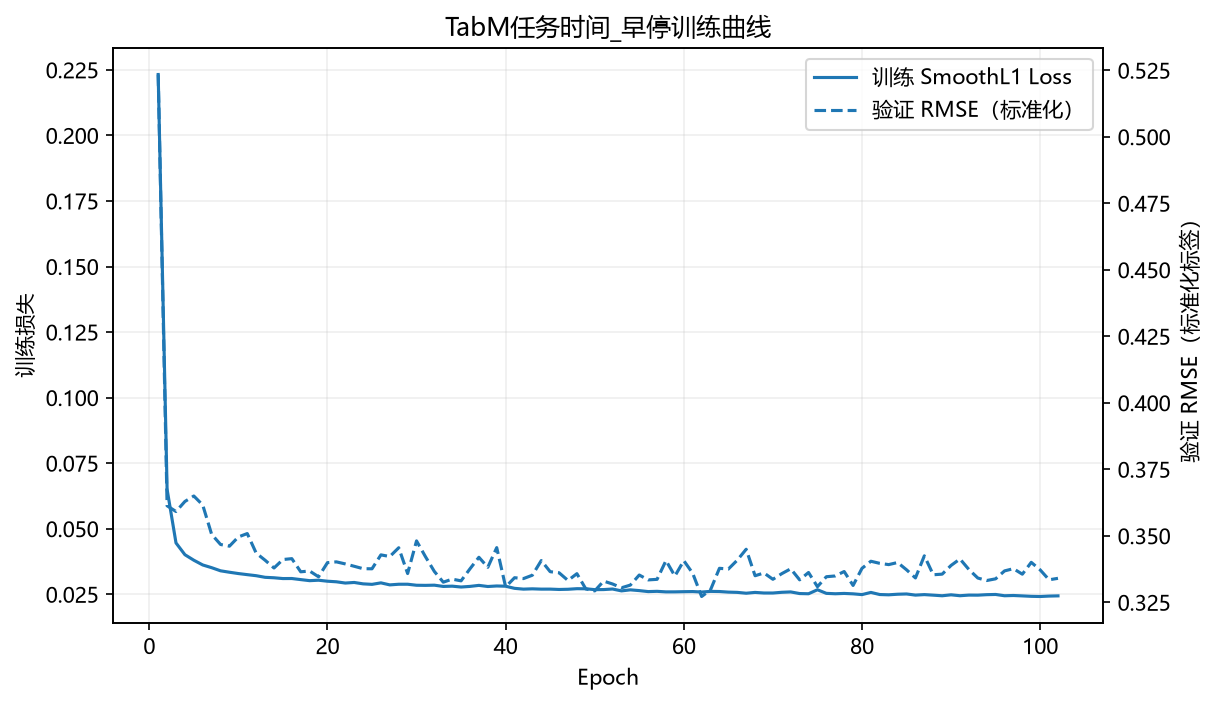

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务时间_早停训练曲线.png


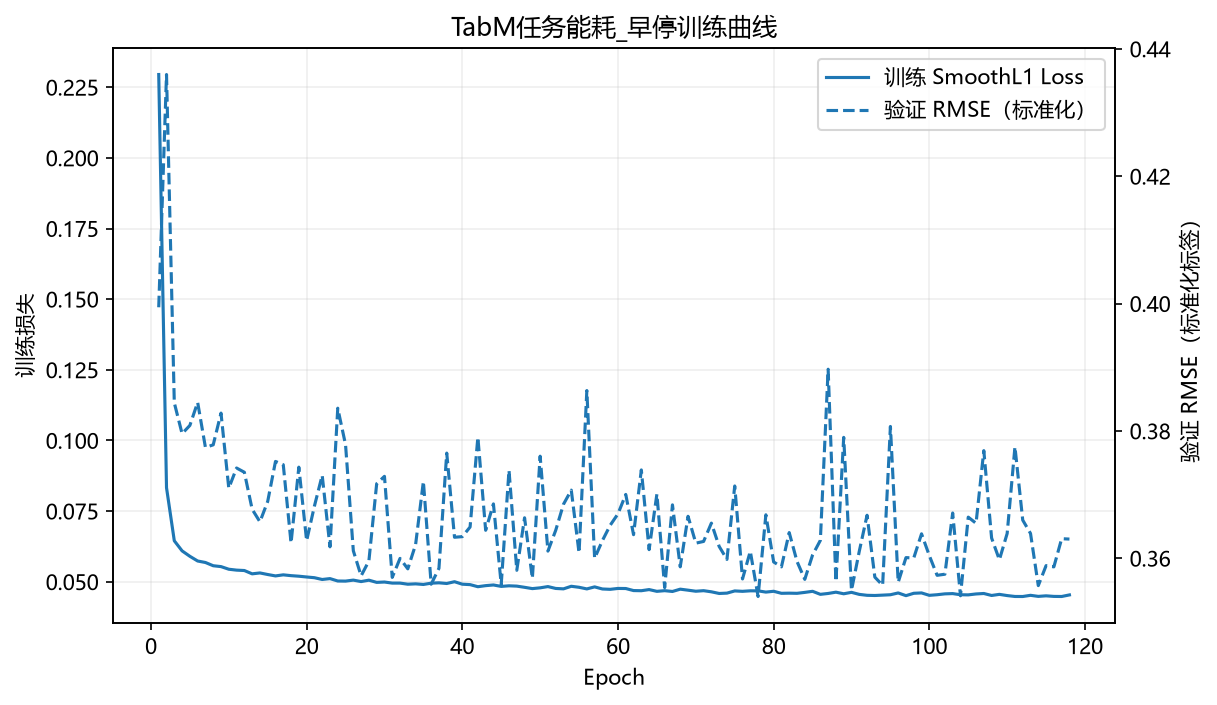

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务能耗_早停训练曲线.png


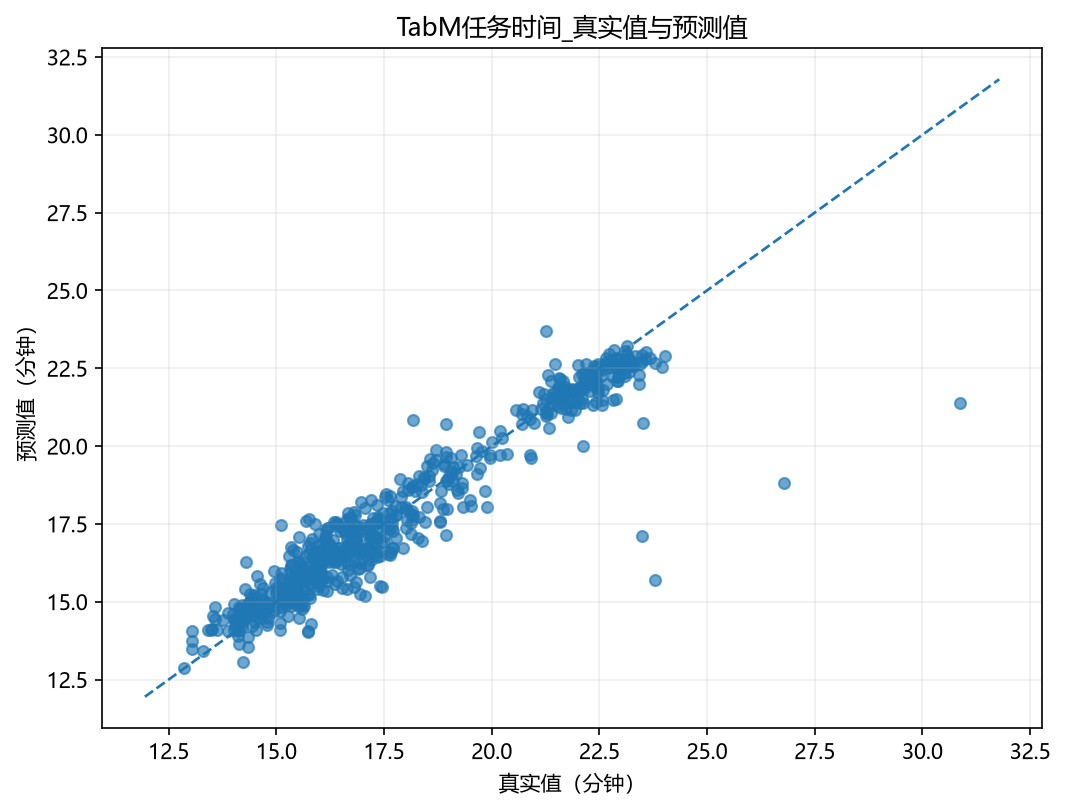

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务时间_真实值与预测值.png


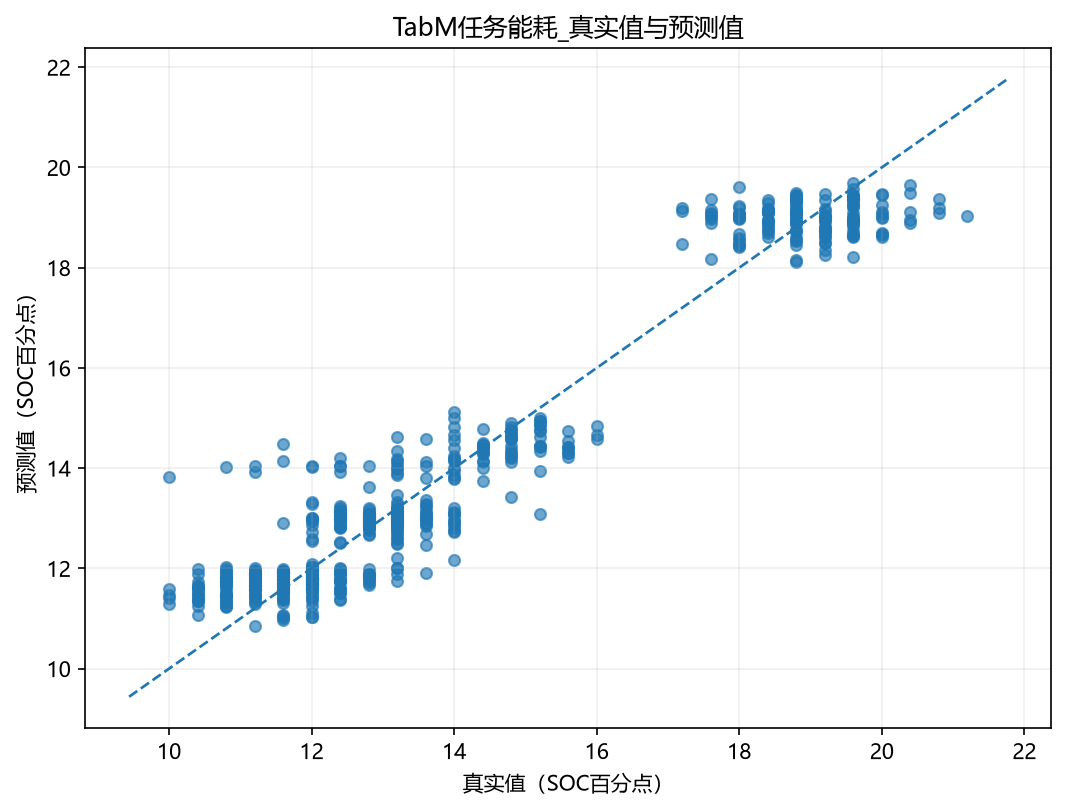

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务能耗_真实值与预测值.png


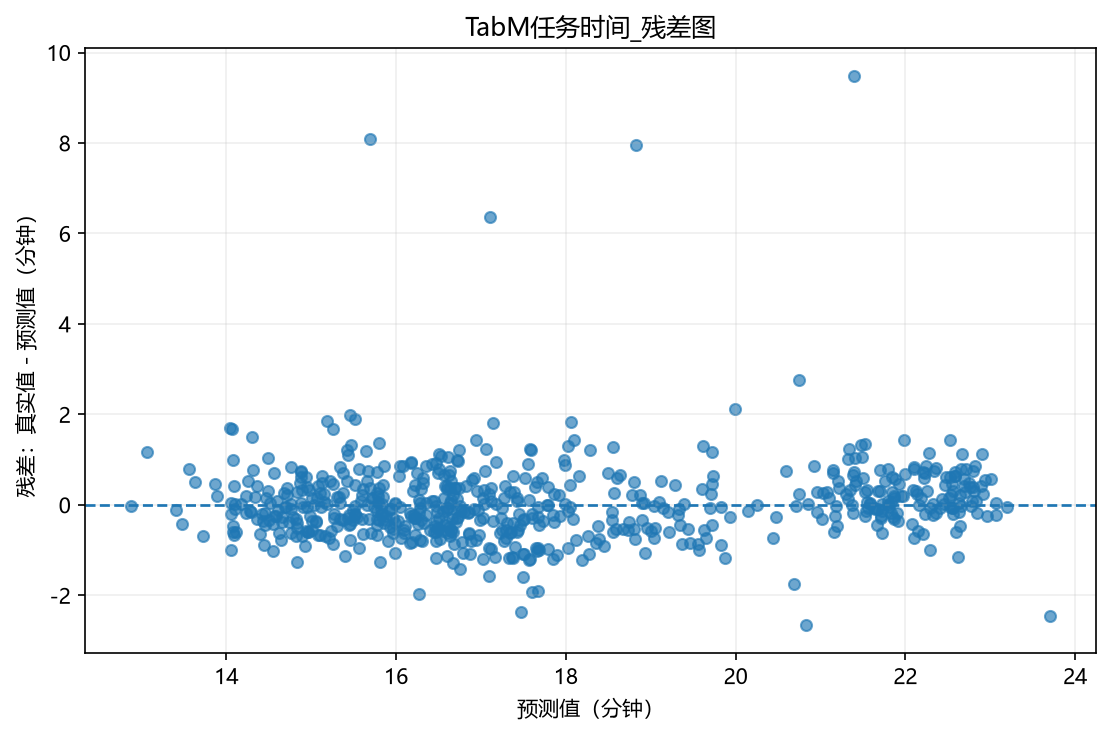

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务时间_残差图.png


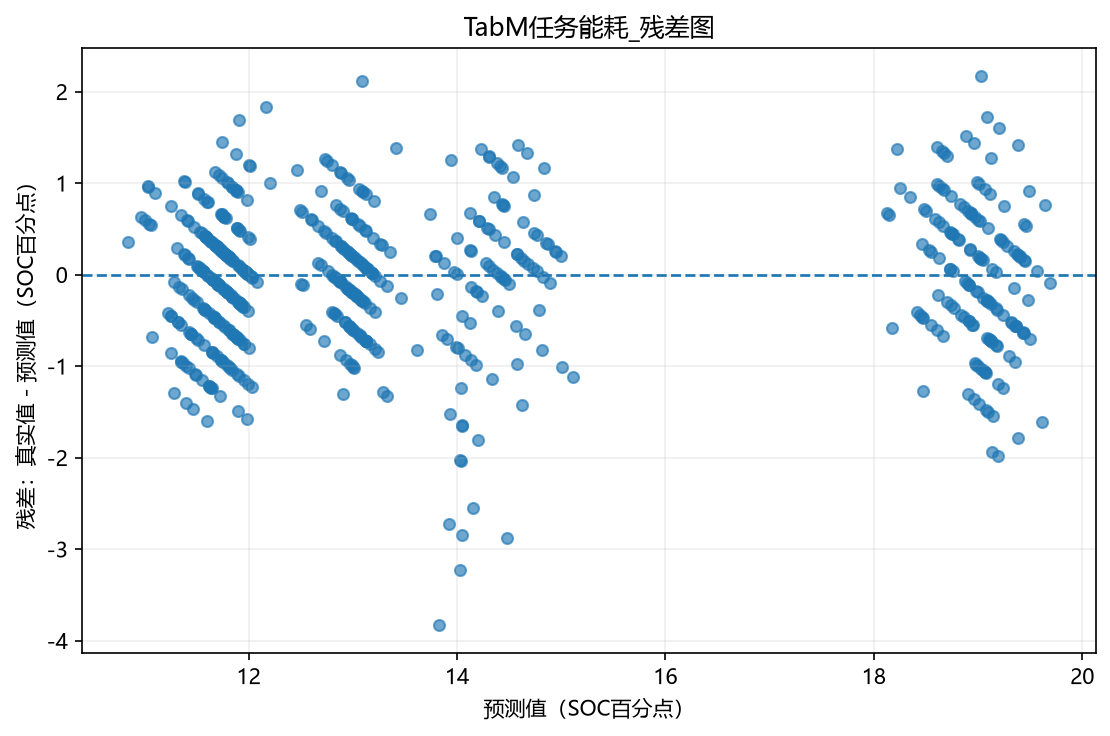

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务能耗_残差图.png


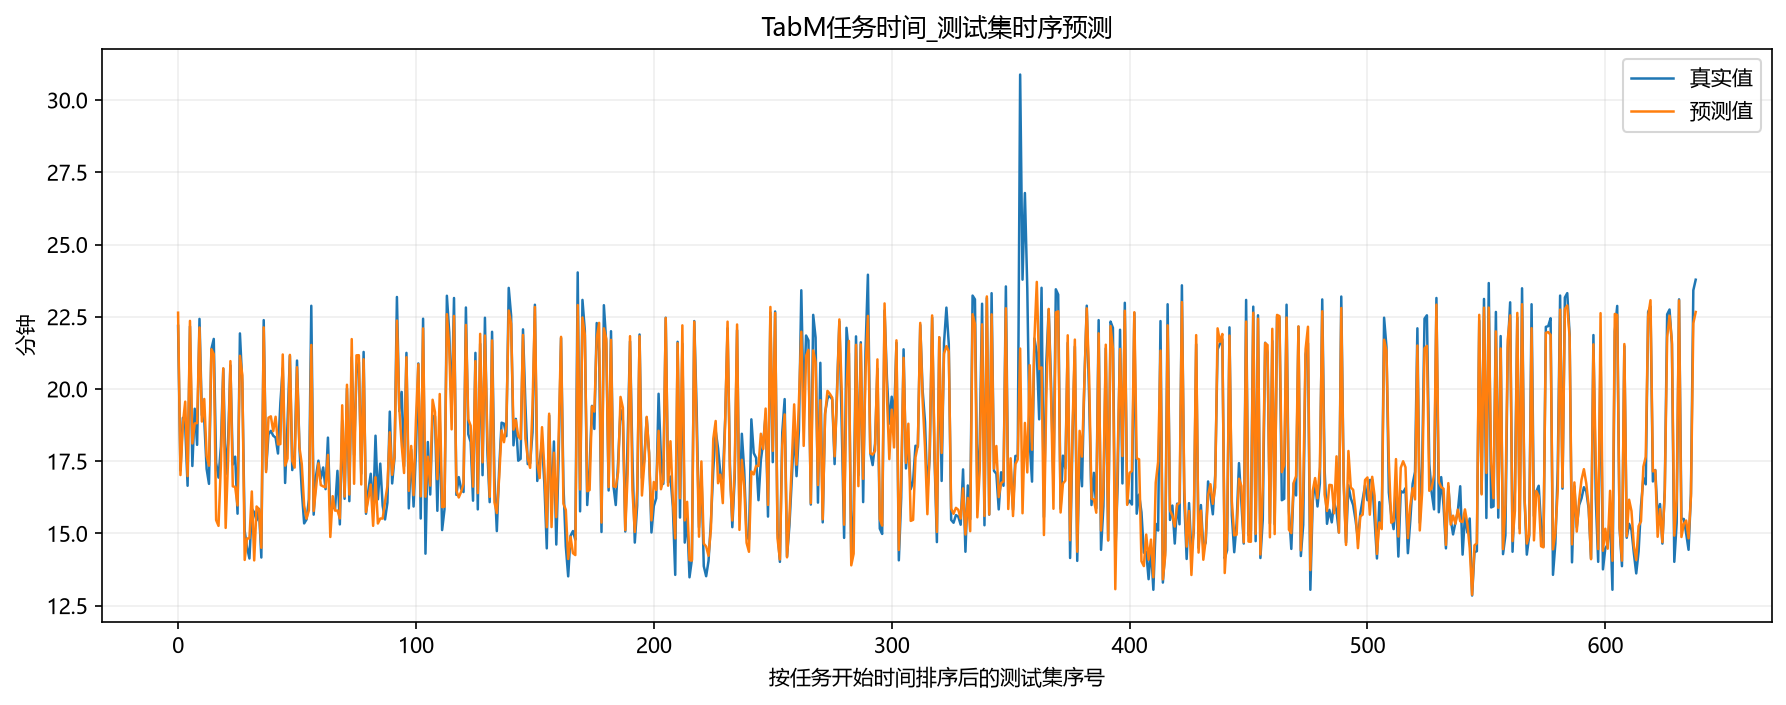

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务时间_测试集时序预测.png


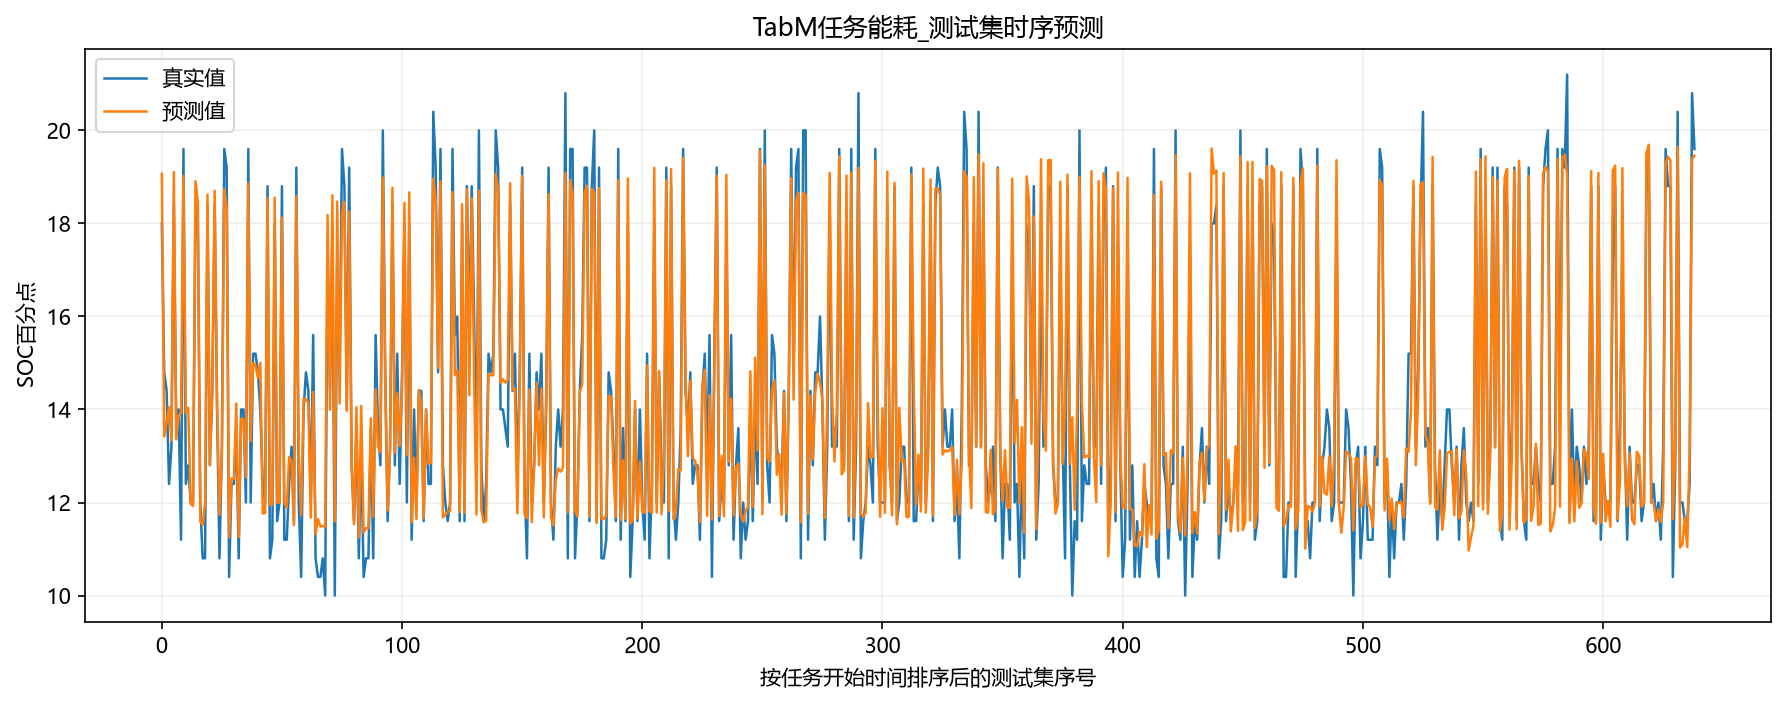

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots\TabM任务能耗_测试集时序预测.png


In [82]:
def safe_filename(title: str) -> str:
    name = re.sub(r"[^0-9A-Za-z一-鿿_-]+", "_", title).strip("_")
    return (name or "plot")[:120] + ".png"


def save_and_display(fig, title: str) -> None:
    path = PLOT_DIR / safe_filename(title)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)
    display(IPythonImage(filename=str(path)))
    print("已保存：", path)


def plot_training_history(history: Dict[str, list], title: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
    ax1.plot(epochs, history["train_loss"], label="训练 SmoothL1 Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("训练损失")
    ax1.grid(alpha=0.2)

    if history["val_rmse_std"]:
        ax2 = ax1.twinx()
        ax2.plot(epochs, history["val_rmse_std"], linestyle="--", label="验证 RMSE（标准化）")
        ax2.set_ylabel("验证 RMSE（标准化标签）")

        lines = ax1.get_lines() + ax2.get_lines()
        ax1.legend(lines, [line.get_label() for line in lines], loc="best")
    else:
        ax1.legend(loc="best")

    ax1.set_title(title)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_actual_vs_predicted(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    lower = float(min(y_true.min(), y_pred.min()))
    upper = float(max(y_true.max(), y_pred.max()))
    padding = max((upper - lower) * 0.05, 1e-6)

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    ax.scatter(y_true, y_pred, s=28, alpha=0.65)
    ax.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        linestyle="--",
        linewidth=1.3,
    )
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_residuals(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.scatter(y_pred, residual, s=28, alpha=0.65)
    ax.axhline(0.0, linestyle="--", linewidth=1.3)
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差：真实值 - 预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_prediction_sequence(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    index = np.arange(len(y_true))

    fig, ax = plt.subplots(figsize=(12.0, 4.8))
    ax.plot(index, y_true, linewidth=1.2, label="真实值")
    ax.plot(index, y_pred, linewidth=1.2, label="预测值")
    ax.set_xlabel("按任务开始时间排序后的测试集序号")
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


# 训练曲线
plot_training_history(time_bundle["history"], "TabM任务时间_早停训练曲线")
plot_training_history(energy_bundle["history"], "TabM任务能耗_早停训练曲线")

# 真实值与预测值
plot_actual_vs_predicted(y_time_test, time_pred, "TabM任务时间_真实值与预测值", "分钟")
plot_actual_vs_predicted(y_energy_test, energy_pred, "TabM任务能耗_真实值与预测值", "SOC百分点")

# 残差
plot_residuals(y_time_test, time_pred, "TabM任务时间_残差图", "分钟")
plot_residuals(y_energy_test, energy_pred, "TabM任务能耗_残差图", "SOC百分点")

# 按时间顺序对比
plot_prediction_sequence(y_time_test, time_pred, "TabM任务时间_测试集时序预测", "分钟")
plot_prediction_sequence(y_energy_test, energy_pred, "TabM任务能耗_测试集时序预测", "SOC百分点")

## 9. 保存指标、预测结果和模型

In [83]:
metrics_table.to_csv(OUTPUT_DIR / "tabm_test_metrics.csv", encoding="utf-8-sig",)
prediction_result.to_csv(
    OUTPUT_DIR / "tabm_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

if SAVE_MODELS:
    torch.save(
        {
            "state_dict": time_bundle["model"].state_dict(),
            "feature_columns": FEATURE_COLS,
            "n_features_after_imputation": int(
                time_bundle["feature_scaler"].n_features_in_
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(time_bundle["best_epoch"]),
            "target": TIME_TARGET,
        },
        OUTPUT_DIR / "tabm_time_state.pt",
    )
    joblib.dump(
        {
            "imputer": time_bundle["imputer"],
            "feature_scaler": time_bundle["feature_scaler"],
            "target_scaler": time_bundle["target_scaler"],
        },
        OUTPUT_DIR / "tabm_time_preprocessors.joblib",
    )

    torch.save(
        {
            "state_dict": energy_bundle["model"].state_dict(),
            "feature_columns": FEATURE_COLS,
            "n_features_after_imputation": int(
                energy_bundle["feature_scaler"].n_features_in_
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(energy_bundle["best_epoch"]),
            "target": ENERGY_TARGET,
        },
        OUTPUT_DIR / "tabm_energy_state.pt",
    )
    joblib.dump(
        {
            "imputer": energy_bundle["imputer"],
            "feature_scaler": energy_bundle["feature_scaler"],
            "target_scaler": energy_bundle["target_scaler"],
        },
        OUTPUT_DIR / "tabm_energy_preprocessors.joblib",
    )

metadata = {
    "data_file": str(DATA_FILE),
    "output_dir": str(OUTPUT_DIR),
    "sample_count": int(len(df)),
    "train_count": int(len(train_df)),
    "test_count": int(len(test_df)),
    "feature_columns": FEATURE_COLS,
    "device": str(DEVICE),
    "tabm_config": TABM_CONFIG,
    "time_best_epoch": int(time_bundle["best_epoch"]),
    "energy_best_epoch": int(energy_bundle["best_epoch"]),
    "time_metrics": time_metrics,
    "energy_metrics": energy_metrics,
}
with (OUTPUT_DIR / "tabm_run_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print("全部结果已保存到：", OUTPUT_DIR.resolve())
print("图表目录：", PLOT_DIR.resolve())

全部结果已保存到： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple
图表目录： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_Simple\plots


## 输出文件

运行完成后，输出目录包括：

- `tabm_test_metrics.csv`：时间与能耗测试集 MAE、RMSE、R²；
- `tabm_test_predictions.csv`：每个测试任务的真实值、预测值和残差；
- `plots/`：8 张训练与预测图；
- `tabm_time_state.pt`、`tabm_energy_state.pt`：模型参数；
- `tabm_time_preprocessors.joblib`、`tabm_energy_preprocessors.joblib`：填补器、特征标准化器和标签标准化器；
- `tabm_run_metadata.json`：运行配置和指标。